# Installs & Imports

In [ ]:
!pip install -q pymc

In [ ]:
import warnings
import numpy as np
from abc import ABC, abstractmethod
from scipy.stats import norm, poisson
from scipy.special import logsumexp, gammaln
from scipy.optimize import minimize_scalar
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pymc as pm

np.random.seed(42)

# Data Generation

In [ ]:
# Simulate the true data-generating process
# Poisson-distributed: discrete, non-negative, variance = mean.
# State: x_t = x_{t-1} + w_t, w_t ~ N(0, sigma^2)
# Observation: y_t ~ Poisson(exp(x_t))
def simulate_poisson_ssm(T, sigma, x0):
    """
    Draw from the Poisson state space model.

    Control over the simulation data allows us to evaluate
    state estimation and parameter recovery.
    """
    increments = np.insert(np.random.normal(0, sigma, T - 1), 0, 0.0)
    x = x0 + np.cumsum(increments)
    y = np.random.poisson(np.exp(x))
    return x, y

In [ ]:
# Parameters
SIGMA_TRUE = 0.15
X0 = 2.0
T_TOTAL = 500
T_TRAIN = 450
T_TEST = T_TOTAL - T_TRAIN

In [ ]:
# Generate and split the data
x_true, y_all = simulate_poisson_ssm(T_TOTAL, SIGMA_TRUE, X0)
y_train, y_test = y_all[:T_TRAIN], y_all[T_TRAIN:]
x_train, x_test = x_true[:T_TRAIN], x_true[T_TRAIN:]

print(f"True sigma = {SIGMA_TRUE},  T_train = {T_TRAIN},  T_test = {T_TEST}")
print(f"Count range: {y_all.min()} - {y_all.max()}")

True sigma = 0.15,  T_train = 450,  T_test = 50
Count range: 0 - 84


# Model Fitting

## Base Class

In [ ]:
# Base class: shared interface for all models
class PoissonSSMBase(ABC):
    """
    All models must implement the following four methods.

    fit(y_train) -> fit the model to training data, return self
    get_smoothed_states() -> (T_train,) smoothed latent state estimates
    get_sigma() -> scalar point estimate of sigma
    forecast_state_samples() -> (n_samples, n_steps) latent state forecasts
    """

    @abstractmethod
    def fit(self, y_train):
        ...

    @abstractmethod
    def get_smoothed_states(self):
        ...

    @abstractmethod
    def get_sigma(self):
        ...

    @abstractmethod
    def forecast_state_samples(self, n_steps, n_samples=3000):
        ...

## Statsmodels Gaussian

In [ ]:
# Model 1: Statsmodels Gaussian Kalman filter on log-transformed counts
class GaussianKFSSM(PoissonSSMBase):
    """
    Gaussian Kalman filter applied to log-transformed count data.

    Strategy: z_t = log(y_t + 0.5), then fit a Gaussian local level
    model to z_t.
    """

    def __init__(self):
        self.sigma_w_hat = None
        self._smoothed = None
        self._filtered_last = None
        self._filtered_last_var = None

    def fit(self, y_train):
        z = np.log(y_train.astype(float) + 0.5)

        model = sm.tsa.UnobservedComponents(z, level="local level")
        result = model.fit(disp=False)

        # Safe parameter extraction with fallback
        params = result.params
        if hasattr(params, 'index'):
            # pandas Series: search by name
            param_names = list(params.index)
            try:
                level_key = [k for k in param_names if "level" in k.lower()][0]
                level_var = params[level_key]
            except (IndexError, KeyError):
                level_var = params.iloc[1]
        else:
            # plain ndarray: [sigma2.irregular, sigma2.level]
            level_var = params[1]

        self.sigma_w_hat = np.sqrt(max(level_var, 1e-10))

        self._smoothed = result.smoothed_state[0]
        self._filtered_last = result.filtered_state[0, -1]
        self._filtered_last_var = result.filtered_state_cov[0, 0, -1]

        return self

    def get_smoothed_states(self):
        return self._smoothed

    def get_sigma(self):
        return self.sigma_w_hat

    def forecast_state_samples(self, n_steps, n_samples=3000):
        starts = np.random.normal(
            self._filtered_last,
            np.sqrt(self._filtered_last_var),
            size=n_samples,
        )
        increments = np.random.normal(
            0,
            self.sigma_w_hat,
            size=(n_samples, n_steps)
        )
        return starts[:, None] + np.cumsum(increments, axis=1)

In [ ]:
# Fit the model
print("Model 1: Statsmodels Gaussian On Log-Counts")
m1 = GaussianKFSSM().fit(y_train)
print(f"  sigma_hat = {m1.get_sigma():.4f} (in log-transformed space; "
      f"not comparable to true sigma)")

Model 1: Statsmodels Gaussian On Log-Counts
  sigma_hat = 0.1287 (in log-transformed space; not comparable to true sigma)


## Laplace Approximation

In [ ]:
# Model 2: Laplace Approximation
# MAP + Gaussian approximation to the posterior
# Poisson likelihood
# Newton on tridiagonal Hessian
class LaplaceApproxSSM(PoissonSSMBase):
    """
    Laplace approximation for the Poisson SSM, implemented from scratch.
    This attempts to be similar to the algorithm that INLA and TMB use.

    Strategy:
      For a given sigma, the posterior over states is
        p(x | y, sigma) proportional to p(y | x) * p(x | sigma)

      Step 1: Find x* = argmax p(x | y, sigma) via Newton's method.
              The Hessian is tridiagonal from the random walk prior,
              so each Newton step costs O(T) via the Thomas algorithm.

      Step 2: Approximate p(x | y, sigma) ~= N(x*, Sigma) where
              Sigma = (-H)^{-1} and H is the Hessian at x*.
              Under this Gaussian approximation, the mode (MAP) equals
              the mean, so x* is the approximate posterior mean.

      Step 3: The Laplace-approximated marginal likelihood is:
              log p(y|sigma) ~= log p(y,x*|sigma)
                              + (T/2) log(2*pi)
                              - (1/2) log det(-H)
              Optimize sigma by maximizing this.

    Prior on x:
      x_0 ~ N(mu_0, kappa^2) [broad: kappa = 10]
      x_t | x_{t-1} ~ N(x_{t-1}, sigma^2) [random walk]

    Prior precision matrix Q:
      The prior log-density is a quadratic form -0.5 * (x - mu)^T Q (x - mu)
      (plus normalising constants). Q is tridiagonal and built from two
      kinds of contributions:

        (a) Initial state:   x_0 ~ N(mu_0, kappa^2)
            Adds 1/kappa^2 to Q[0, 0].

        (b) Each transition:  x_t | x_{t-1} ~ N(x_{t-1}, sigma^2)
            Adds 1/sigma^2 to Q[t-1, t-1] and Q[t, t],
            and -1/sigma^2 to Q[t-1, t] and Q[t, t-1].

      The method _prior_precision_diags builds Q by accumulating these
      contributions with non-overlapping slice additions. This eliminates
      the need for per-boundary special cases in the gradient and Hessian.
    """

    def __init__(self, kappa=10.0):
        self.sigma_hat = None
        self._x_map = None
        self._posterior_var = None
        self._kappa = kappa
        self._mu0 = None

    # Prior precision matrix:
    # Factored into its own method so the gradient and Hessian
    # can both re-use it
    def _prior_precision_diags(self, sigma, T):
        """
        Build the diagonal and off-diagonal of the prior precision
        matrix Q by accumulating contributions from each term:

          x_0 ~ N(mu_0, kappa^2) --> adds 1/kappa^2 to main[0]
          x_t | x_{t-1} ~ N(x_{t-1}, sigma^2) --> each transition adds:
              1/sigma^2 to main[t-1] and main[t],
              and -1/sigma^2 to off[t-1]
        """
        sigma2 = sigma ** 2
        main = np.zeros(T)
        main[0] += 1.0 / self._kappa ** 2

        if T > 1:
            main[:-1] += 1.0 / sigma2  # left side of each transition
            main[1:] += 1.0 / sigma2   # right side of each transition
            off = np.full(T - 1, -1.0 / sigma2)
        else:
            off = np.empty(0)

        return main, off

    # Tridiagonal matvec
    @staticmethod
    def _tridiag_matvec(main, off, x):
        """Compute A @ x where A is symmetric tridiagonal."""
        result = main * x
        if len(off) > 0:
            result[:-1] += off * x[1:]
            result[1:] += off * x[:-1]
        return result

    # Tridiagonal linear algebra:
    # All three routines exploit the tridiagonal structure of the
    # negative Hessian, reducing O(T^3) dense operations to O(T)
    @staticmethod
    def _solve_tridiag(main_diag, off_diag, rhs):
        """
        Thomas algorithm: solve Ax = b where A is symmetric positive
        definite tridiagonal with given diagonal and off-diagonal.
        Cost: O(T).
        """
        n = len(main_diag)
        d = main_diag.copy()
        b = rhs.copy()
        e = off_diag.copy()

        for i in range(1, n):
            m = e[i - 1] / d[i - 1]
            d[i] -= m * e[i - 1]
            b[i] -= m * b[i - 1]

        x = np.zeros(n)
        x[-1] = b[-1] / d[-1]
        for i in range(n - 2, -1, -1):
            x[i] = (b[i] - e[i] * x[i + 1]) / d[i]

        return x

    @staticmethod
    def _log_det_tridiag(main_diag, off_diag):
        """
        Log-determinant of an SPD tridiagonal matrix via LDL pivots.
        Cost: O(T).
        """
        n = len(main_diag)
        d = main_diag[0]
        log_det = np.log(d)

        for i in range(1, n):
            d = main_diag[i] - off_diag[i - 1] ** 2 / d
            log_det += np.log(d)

        return log_det

    @staticmethod
    def _inverse_diag_tridiag(main_diag, off_diag):
        """
        Diagonal of the inverse of an SPD tridiagonal matrix.
        Cost: O(T).

        Uses LDL factorisation with backward recursion:
          v_{T-1} = 1 / d_{T-1}
          v_i = 1 / d_i + l_{i+1}^2 * v_{i+1}
        """
        n = len(main_diag)

        d = np.zeros(n)
        l = np.zeros(max(n - 1, 0))
        d[0] = main_diag[0]
        for i in range(1, n):
            l[i - 1] = off_diag[i - 1] / d[i - 1]
            d[i] = main_diag[i] - l[i - 1] * off_diag[i - 1]

        v = np.zeros(n)
        v[-1] = 1.0 / d[-1]
        for i in range(n - 2, -1, -1):
            v[i] = 1.0 / d[i] + l[i] ** 2 * v[i + 1]

        return v

    # Log-posterior and its derivatives
    def _log_joint(self, x, y, sigma):
        """
        log p(y, x | sigma) = log p(y | x) + log p(x | sigma)

        Includes all normalising constants (needed for the marginal
        likelihood computation to be correct).
        """
        T = len(y)
        sigma2 = sigma ** 2
        kappa2 = self._kappa ** 2
        mu0 = self._mu0

        # log p(y | x) = Sum [y_t * x_t - exp(x_t) - log(y_t!)]
        log_obs = np.sum(y * x - np.exp(x) - gammaln(y + 1))

        # log p(x | sigma)
        dx = np.diff(x)
        log_prior = (
            -0.5 * np.log(2 * np.pi * kappa2)
            - 0.5 * (x[0] - mu0) ** 2 / kappa2
            - 0.5 * max(T - 1, 0) * np.log(2 * np.pi * sigma2)
            - 0.5 * np.sum(dx ** 2) / sigma2
        )

        return log_obs + log_prior

    def _gradient(self, x, y, sigma):
        """
        Gradient of log p(y, x | sigma) with respect to x.

        Observation contribution: y_t - exp(x_t)
        Prior contribution: -Q @ x + b, where b_0 = mu_0/kappa^2
                            and b_t = 0 for t > 0.

        The prior precision matrix Q is built by _prior_precision_diags.
        This avoids manual boundary-index logic.
        """
        T = len(y)

        # Observation gradient (vectorized)
        g = (y - np.exp(x)).astype(float)

        # Prior gradient: d/dx [ -0.5 x^T Q x + b^T x ] = -Q x + b
        main_q, off_q = self._prior_precision_diags(sigma, T)
        g -= self._tridiag_matvec(main_q, off_q, x)
        g[0] += self._mu0 / self._kappa ** 2

        return g

    def _neg_hessian_diags(self, x, sigma):
        """
        Diagonal and off-diagonal of -H, the negative Hessian of
        log p(y, x | sigma).

        -H = Q + diag(exp(x))

        where Q is the prior precision matrix. Both terms are positive
        (semi-)definite, so -H is strictly positive definite,
        guaranteeing strict concavity and a unique MAP.

        Q is built by _prior_precision_diags; we simply add the
        observation contribution diag(exp(x)) to its diagonal.
        """
        T = len(x)
        main_q, off_q = self._prior_precision_diags(sigma, T)
        main_q += np.exp(x) # observation contribution
        return main_q, off_q

    # MAP finding
    def _find_map(self, y, sigma, max_iter=100, tol=1e-10):
        """
        Find x* = argmax log p(x | y, sigma) using Newton's method.

        Each iteration:
          1. Compute gradient g and negative Hessian -H at current x
          2. Solve the tridiagonal system (-H) delta_x = g [O(T)]
          3. Backtracking line search along delta_x
        """
        x = np.log(y.astype(float) + 0.5)

        for iteration in range(max_iter):
            g = self._gradient(x, y, sigma)
            main, off = self._neg_hessian_diags(x, sigma)

            delta = self._solve_tridiag(main, off, g)

            # Backtracking line search (Armijo condition)
            step = 1.0
            current_obj = self._log_joint(x, y, sigma)
            directional_deriv = np.dot(g, delta)

            for _ in range(30):
                new_obj = self._log_joint(x + step * delta, y, sigma)
                if new_obj >= current_obj + 1e-4 * step * directional_deriv:
                    break
                step *= 0.5

            x = x + step * delta

            if np.max(np.abs(step * delta)) < tol:
                break

        return x

    # Laplace marginal likelihood
    def _laplace_marginal_loglik(self, y, sigma):
        """
        Laplace approximation to log p(y | sigma):

          log p(y|sigma) ~= log p(y, x* | sigma)
                          + (T/2) log(2*pi)
                          - (1/2) log det(-H(x*))
        """
        T = len(y)
        x_map = self._find_map(y, sigma)

        log_joint_at_map = self._log_joint(x_map, y, sigma)
        main, off = self._neg_hessian_diags(x_map, sigma)
        log_det_neg_H = self._log_det_tridiag(main, off)

        return (log_joint_at_map
                + 0.5 * T * np.log(2 * np.pi)
                - 0.5 * log_det_neg_H)

    # Fitting
    def fit(self, y_train):
        self._mu0 = np.log(y_train[0] + 0.5)

        # Boundary check for sigma optimization
        bounds = (0.01, 1.0)
        result = minimize_scalar(
            lambda sigma: -self._laplace_marginal_loglik(y_train, sigma),
            bounds=bounds,
            method="bounded",
        )
        self.sigma_hat = result.x

        tol = 0.005
        if abs(self.sigma_hat - bounds[0]) < tol or abs(self.sigma_hat - bounds[1]) < tol:
            warnings.warn(
                f"Laplace sigma_hat = {self.sigma_hat:.4f} is at the edge of "
                f"the search bounds {bounds}. The true optimum may lie "
                f"outside this range. Consider widening the bounds."
            )

        self._x_map = self._find_map(y_train, self.sigma_hat)
        main, off = self._neg_hessian_diags(self._x_map, self.sigma_hat)
        self._posterior_var = self._inverse_diag_tridiag(main, off)

        return self

    def get_smoothed_states(self):
        """
        The MAP x*. Under the Laplace Gaussian approximation to the
        posterior, the mode equals the mean, so this is the approximate
        posterior mean, directly comparable to PyMC's posterior mean.
        """
        return self._x_map

    def get_sigma(self):
        return self.sigma_hat

    def get_posterior_std(self):
        """Approximate posterior std dev at each time step."""
        return np.sqrt(self._posterior_var)

    def forecast_state_samples(self, n_steps, n_samples=3000):
        """
        Sample from the approximate marginal posterior of x_T,
        then propagate forward through the random walk.

        NOTE: uses the point estimate sigma_hat, so forecast intervals
        do NOT account for parameter uncertainty, unlike PyMC.
        """
        starts = np.random.normal(
            self._x_map[-1],
            np.sqrt(self._posterior_var[-1]),
            size=n_samples,
        )
        increments = np.random.normal(0, self.sigma_hat,
                                      size=(n_samples, n_steps))
        return starts[:, None] + np.cumsum(increments, axis=1)

In [ ]:
# Fit the model
print("Model 2: Laplace Approximation")
m2 = LaplaceApproxSSM().fit(y_train)
print(f"  sigma_hat = {m2.get_sigma():.4f}")

Model 2: Laplace Approximation
  sigma_hat = 0.1592


## PyMC Bayesian MCMC

In [ ]:
# Model 3: PyMC Bayesian MCMC
# Poisson likelihood with Bayesian MCMC; full posterior
class BayesianPoissonSSM(PoissonSSMBase):
    """
    Poisson SSM with full Bayesian inference via PyMC's NUTS.

    The model specifies the true generative process:
      x_t = x_{t-1} + w_t, w_t ~ N(0, sigma^2)
      y_t ~ Poisson(exp(x_t))

    NUTS (Hamiltonian Monte Carlo) explores the joint posterior of
    all T latent states and sigma simultaneously. This approach has the
    correct likelihood and full uncertainty quantification.
    """

    def __init__(self, n_draws=3000, n_tune=2000):
        self.n_draws = n_draws
        self.n_tune = n_tune
        self.x_posterior = None
        self.sigma_posterior = None

    def fit(self, y_train):
        T_train = len(y_train)

        with pm.Model():
            sigma = pm.HalfCauchy("sigma", beta=1.0)
            x0 = pm.Normal("x0", mu=np.log(y_train[0] + 0.5), sigma=1.0)
            z = pm.Normal(
                "z",
                mu=0,
                sigma=1.0,
                shape=T_train - 1
            )
            innovations = pm.Deterministic("innovations", sigma * z)
            x = pm.Deterministic(
                "x",
                pm.math.concatenate([[x0], x0 + pm.math.cumsum(innovations)])
            )

            pm.Poisson("y_obs", mu=pm.math.exp(x), observed=y_train)

            trace = pm.sample(
                self.n_draws,
                tune=self.n_tune,
                chains=2,
                cores=1,
                target_accept=0.95,
                random_seed=42,
                progressbar=True,
            )

        self.x_posterior = trace.posterior["x"].values.reshape(-1, T_train)
        self.sigma_posterior = trace.posterior["sigma"].values.flatten()

        return self

    def get_smoothed_states(self):
        return self.x_posterior.mean(axis=0)

    def get_sigma(self):
        return self.sigma_posterior.mean()

    def forecast_state_samples(self, n_steps, n_samples=3000):
        """
        For each posterior draw of (x_T, sigma), propagate the random
        walk forward. This accounts for both state and parameter
        uncertainty.
        """
        n_avail = len(self.sigma_posterior)
        idx = np.random.choice(n_avail, size=n_samples, replace=True)

        starts = self.x_posterior[idx, -1]
        sigmas = self.sigma_posterior[idx]

        increments = (np.random.standard_normal((n_samples, n_steps))
                      * sigmas[:, None])
        return starts[:, None] + np.cumsum(increments, axis=1)

In [ ]:
# Fit the model
print("Model 3: PyMC Bayesian MCMC")
m3 = BayesianPoissonSSM(n_draws=3000, n_tune=2000).fit(y_train)
print(f"  sigma_hat = {m3.get_sigma():.4f}")

Model 3: PyMC Bayesian MCMC


Output()

  sigma_hat = 0.1618


## Bootstrap Particle Filter

In [ ]:
# Model 4: Particle Filter
# Bootstrap particle filter + backward smoother
# Sequential Monte Carlo approach
class ParticleFilterSSM(PoissonSSMBase):
    """
    Bootstrap particle filter + backward simulation smoother for
    the Poisson SSM.

    The particle filter represents the filtering distribution as a
    weighted sample of particles. At each time step:
      1. PROPAGATE particles through the state equation
      2. WEIGHT each particle by the Poisson likelihood of y_t
      3. RESAMPLE to concentrate particles in high-likelihood regions

    No distributional assumptions in the algorithm.
    Handles the Poisson likelihood directly, without linearization
    or Gaussian approximation.

    For smoothing, backward simulation refines the filtered estimates using
    future observations.
    """

    def __init__(self, n_particles=3000):
        self.N = n_particles
        self.sigma_hat = None
        self._particles = None
        self._log_weights = None
        self._smoothed_mean = None

    # Bootstrap Particle Filter
    def _run_filter(self, y, sigma, rng=None):
        """
        Run the bootstrap particle filter.

        Parameters:
        y: (T,) observations
        sigma: state noise std dev
        rng: numpy Generator. Passing a fixed-seed generator during
             the grid search ensures the same particles are used for
             every candidate sigma, making the log-likelihood surface
             smooth and the optimizer reliable.
        """
        if rng is None:
            rng = np.random.default_rng()

        T_obs = len(y)
        N = self.N

        particles = np.zeros((T_obs, N))
        log_weights = np.zeros((T_obs, N))
        filtered_means = np.zeros(T_obs)
        loglik = 0.0

        current = rng.normal(np.log(y[0] + 0.5), 1.0, size=N)

        for t in range(T_obs):
            if t > 0:
                current = current + rng.normal(0, sigma, size=N)

            rates = np.exp(np.clip(current, -20, 20))
            lw = poisson.logpmf(y[t], mu=rates)

            max_lw = np.max(lw)
            w = np.exp(lw - max_lw)
            w_sum = np.sum(w)
            w_norm = w / w_sum

            particles[t] = current.copy()
            log_weights[t] = np.log(w_norm + 1e-300)

            loglik += max_lw + np.log(w_sum) - np.log(N)
            filtered_means[t] = np.sum(w_norm * current)

            current = current[self._systematic_resample(w_norm, rng)]

        return filtered_means, particles, log_weights, loglik

    @staticmethod
    def _systematic_resample(weights, rng):
        N = len(weights)
        positions = (np.arange(N) + rng.uniform()) / N
        cumsum = np.cumsum(weights)
        return np.clip(np.searchsorted(cumsum, positions), 0, N - 1)

    # Backward Simulation Smoother
    def _backward_smoother(
            self,
            particles,
            log_weights,
            sigma,
            n_trajectories=200,
            rng=None
        ):
        """
        Backward simulation particle smoother

        The time loop is inherently sequential: each t depends on the
        sampled x_{t+1}.

        Parameters:
        rng: numpy Generator. If None, a fresh unseeded generator is
             created. Pass a seeded generator for reproducibility.
        """
        if rng is None:
            rng = np.random.default_rng()

        T_obs, N = particles.shape
        B = n_trajectories
        trajs = np.zeros((B, T_obs))

        w_final = np.exp(log_weights[-1])
        w_final /= w_final.sum()
        trajs[:, -1] = particles[-1, rng.choice(N, size=B, p=w_final)]

        for t in range(T_obs - 2, -1, -1):
            x_next = trajs[:, t + 1]   # (B,)

            # Smoothing weights: filter weight * transition density
            log_trans = norm.logpdf(
                x_next[:, None],           # (B, 1)
                loc=particles[t][None, :], # (1, N)
                scale=sigma,
            )                              # (B, N)

            log_w = log_weights[t][None, :] + log_trans      # (B, N)
            log_w -= logsumexp(log_w, axis=1, keepdims=True)
            w = np.exp(log_w)                                # (B, N)

            # Vectorized categorical sampling with cumsum clamping
            cum_w = np.cumsum(w, axis=1)           # (B, N)
            cum_w[:, -1] = 1.0
            u = rng.uniform(size=B)[:, None]       # (B, 1)
            chosen = np.argmax(cum_w >= u, axis=1) # (B,)
            trajs[:, t] = particles[t, chosen]

        return trajs

    # Parameter Estimation
    def fit(self, y_train):
        """
        Two-step fitting with fixed-seed grid search for smooth
        log-likelihood surface.
        """
        grid_seed = 123

        # Data-adaptive upper bound for sigma grid:
        # Use the empirical std of differenced log-counts as a rough
        # scale, then multiply by 5 with a floor of 1.5 to ensure
        # the grid covers the true sigma even for large values.
        diff_scale = np.std(np.diff(np.log(y_train.astype(float) + 0.5)))
        sigma_upper = max(1.5, 5.0 * diff_scale)

        # Coarse grid
        sigmas = np.linspace(0.02, sigma_upper, 40)
        logliks = np.array([
            self._run_filter(
                y_train,
                s,
                rng=np.random.default_rng(grid_seed)
            )[3]
            for s in sigmas
        ])
        best_idx = np.argmax(logliks)
        best = sigmas[best_idx]

        # Boundary check for coarse grid
        if best_idx in (0, len(sigmas) - 1):
            warnings.warn(
                f"PF coarse grid optimum sigma = {best:.4f} is at the edge "
                f"of [{sigmas[0]:.3f}, {sigmas[-1]:.3f}]. The true optimum "
                f"may lie outside this range."
            )

        # Fine grid
        sigmas_fine = np.linspace(max(0.01, best - 0.04), best + 0.04, 40)
        logliks_fine = np.array([
            self._run_filter(
                y_train,
                s,
                rng=np.random.default_rng(grid_seed)
            )[3]
            for s in sigmas_fine
        ])
        fine_best_idx = np.argmax(logliks_fine)
        self.sigma_hat = sigmas_fine[fine_best_idx]

        # Boundary check for fine grid
        if fine_best_idx in (0, len(sigmas_fine) - 1):
            warnings.warn(
                f"PF fine grid optimum sigma = {self.sigma_hat:.4f} is at "
                f"the edge of [{sigmas_fine[0]:.3f}, {sigmas_fine[-1]:.3f}]."
                f" Consider widening the search."
            )

        # Final filter + smoother with fresh randomness
        _, self._particles, self._log_weights, _ = \
            self._run_filter(y_train, self.sigma_hat)

        smoother_rng = np.random.default_rng(456)
        trajs = self._backward_smoother(
            self._particles,
            self._log_weights,
            self.sigma_hat,
            n_trajectories=200,
            rng=smoother_rng,
        )
        self._smoothed_mean = trajs.mean(axis=0)

        return self

    def get_smoothed_states(self):
        return self._smoothed_mean

    def get_sigma(self):
        return self.sigma_hat

    def forecast_state_samples(self, n_steps, n_samples=3000):
        """
        Propagate the final particle cloud forward.
        Uses point estimate sigma_hat (no parameter uncertainty).
        """
        w = np.exp(self._log_weights[-1])
        w /= w.sum()
        starts = self._particles[
            -1,
            np.random.choice(self.N, size=n_samples, p=w)
        ]

        increments = np.random.normal(
            0,
            self.sigma_hat,
            size=(n_samples, n_steps)
        )
        return starts[:, None] + np.cumsum(increments, axis=1)

In [ ]:
# Fit the model
print("Model 4: Particle Filter + Smoother")
m4 = ParticleFilterSSM(n_particles=3000).fit(y_train)
print(f"  sigma_hat = {m4.get_sigma():.4f}")

Model 4: Particle Filter + Smoother
  sigma_hat = 0.1540


# Results Evaluation

## State Estimation

In [ ]:
# RMSE of smoothed states vs. true x_t
def state_rmse(x_true, x_est):
    """RMSE between true and estimated latent states. Lower = better."""
    return np.sqrt(np.mean((x_true - x_est) ** 2))

In [ ]:
# Task 1: State Estimation
rmse1 = state_rmse(x_train, m1.get_smoothed_states())
rmse2 = state_rmse(x_train, m2.get_smoothed_states())
rmse3 = state_rmse(x_train, m3.get_smoothed_states())
rmse4 = state_rmse(x_train, m4.get_smoothed_states())

print("=" * 70)
print("  TASK 1: STATE ESTIMATION; RMSE vs. true x_t (lower = better)")
print("=" * 70)
print(f"  Statsmodels (Gaussian KF): {rmse1:.4f}")
print(f"  Laplace (MAP ~= post. mean): {rmse2:.4f}")
print(f"  PyMC (posterior mean): {rmse3:.4f}")
print(f"  Particle Filter (smoothed): {rmse4:.4f}")

  TASK 1: STATE ESTIMATION; RMSE vs. true x_t (lower = better)
  Statsmodels (Gaussian KF): 0.2041
  Laplace (MAP ~= post. mean): 0.1835
  PyMC (posterior mean): 0.1846
  Particle Filter (smoothed): 0.1848


## Parameter Recovery

In [ ]:
# Task 2: Parameter Recovery
# Estimated sigma vs. true sigma
# Not done for first model as it estimates sigma in a transformed space
print("=" * 70)
print(f"  TASK 2: PARAMETER RECOVERY; true sigma = {SIGMA_TRUE}")
print("=" * 70)
print(f"  Laplace sigma_hat = {m2.get_sigma():.4f}  "
      f"|error| = {abs(m2.get_sigma() - SIGMA_TRUE):.4f}")
print(f"  PyMC sigma_hat = {m3.get_sigma():.4f}  "
      f"|error| = {abs(m3.get_sigma() - SIGMA_TRUE):.4f}")
print(f"  PF sigma_hat = {m4.get_sigma():.4f}  "
      f"|error| = {abs(m4.get_sigma() - SIGMA_TRUE):.4f}")

  TASK 2: PARAMETER RECOVERY; true sigma = 0.15
  Laplace sigma_hat = 0.1592  |error| = 0.0092
  PyMC sigma_hat = 0.1618  |error| = 0.0118
  PF sigma_hat = 0.1540  |error| = 0.0040


## Forecasting

In [ ]:
# MAE and log predictive probability on held-out data
def forecast_metrics(y_test, state_samples):
    """
    Evaluate forecasts of count data.

    Point forecast uses the median of predicted rates rather than the
    mean, because the Poisson-lognormal mixture is right-skewed and
    the median is more robust to extreme rate samples.

    Returns
    -------
    mean_mae: scalar, mean absolute error averaged over horizon
    mean_lpd: scalar, mean log predictive probability over horizon
    per_step_lpd: (H,) log predictive probability at each forecast step
    """
    S = state_samples.shape[0]
    rates = np.exp(np.clip(state_samples, -20, 20))

    maes = np.abs(y_test - np.median(rates, axis=0))

    log_probs = poisson.logpmf(y_test[None, :], mu=rates)
    per_step_lpd = logsumexp(log_probs, axis=0) - np.log(S)

    return np.mean(maes), np.mean(per_step_lpd), per_step_lpd

In [ ]:
# Task 3: Forecasting
print(f"Generating {T_TEST}-step-ahead forecasts...")
fc1 = m1.forecast_state_samples(T_TEST)
fc2 = m2.forecast_state_samples(T_TEST)
fc3 = m3.forecast_state_samples(T_TEST)
fc4 = m4.forecast_state_samples(T_TEST)

mae1, lpd1, lpd_steps1 = forecast_metrics(y_test, fc1)
mae2, lpd2, lpd_steps2 = forecast_metrics(y_test, fc2)
mae3, lpd3, lpd_steps3 = forecast_metrics(y_test, fc3)
mae4, lpd4, lpd_steps4 = forecast_metrics(y_test, fc4)

print("\n" + "=" * 70)
print(f"  TASK 3: FORECASTING; {T_TEST} steps ahead")
print("=" * 70)
print(f"  {'Model':<35} {'MAE (lo)':>10} {'LPD (hi)':>10}")
print(f"  {'-' * 58}")
print(f"  {'Statsmodels (Gaussian KF)':<35} {mae1:>10.2f} {lpd1:>10.4f}")
print(f"  {'Laplace (MAP + Gaussian post)':<35} {mae2:>10.2f} {lpd2:>10.4f}")
print(f"  {'PyMC (Bayesian Poisson)':<35} {mae3:>10.2f} {lpd3:>10.4f}")
print(f"  {'Particle Filter (Poisson)':<35} {mae4:>10.2f} {lpd4:>10.4f}")

Generating 50-step-ahead forecasts...

  TASK 3: FORECASTING; 50 steps ahead
  Model                                 MAE (lo)   LPD (hi)
  ----------------------------------------------------------
  Statsmodels (Gaussian KF)                12.74    -3.8147
  Laplace (MAP + Gaussian post)             7.89    -3.6375
  PyMC (Bayesian Poisson)                   8.00    -3.6404
  Particle Filter (Poisson)                 7.65    -3.5983


## Plotting

In [ ]:
# Model color scheme used by all panels
COLORS = {
    "sm": "darkorange",
    "la": "mediumblue",
    "pm": "crimson",
    "pf": "seagreen",
}

In [ ]:
def plot_data_and_rate(ax, t_all, y_all, x_true, t_train_end):
    """Panel 1: observed counts overlaid with the true latent rate."""
    ax.scatter(
        t_all,
        y_all,
        s=8,
        c="steelblue",
        alpha=0.5,
        label="Observed counts"
    )
    ax.plot(
        t_all,
        np.exp(x_true),
        "k-",
        lw=1.5,
        alpha=0.7,
        label="True rate exp(x)"
    )
    ax.axvline(
        t_train_end,
        ls="--",
        c="red",
        lw=1,
        label="Train / test split"
    )
    ax.set_title("Data: Poisson Counts and True Latent Rate")
    ax.set_ylabel("Count / Rate")
    ax.legend(fontsize=7)

In [ ]:
def plot_state_estimation(ax, t_train, x_train, models, rmses):
    """Panel 2: smoothed state estimates from all four models vs. truth."""
    ax.plot(
        t_train,
        x_train,
        "k-",
        lw=2,
        alpha=0.8,
        label="True x_t"
    )

    for (name, key, model), rmse in zip(models, rmses):
        ax.plot(
            t_train,
            model.get_smoothed_states(),
            COLORS[key],
            lw=1.2,
            label=f"{name:<13s} RMSE={rmse:.3f}"
        )

    ax.set_title("State Estimation: Smoothed x_t vs. Truth")
    ax.set_ylabel("x_t (log-rate)")
    ax.legend(fontsize=7)

In [ ]:
def plot_forecast_rates(ax, t_test, y_test, x_test, forecasts):
    """Panel 3: median predicted rate with 80% interval for each model."""
    ax.scatter(
        t_test,
        y_test,
        s=20,
        c="steelblue",
        zorder=5,
        label="Actual counts"
    )
    ax.plot(
        t_test,
        np.exp(x_test),
        "k--",
        lw=1.5,
        label="True rate",
        zorder=4
    )

    for fc, name, key in forecasts:
        rates = np.exp(np.clip(fc, -20, 20))
        color = COLORS[key]
        ax.plot(
            t_test,
            np.median(rates, axis=0),
            color=color,
            lw=1.5,
            label=name
        )
        ax.fill_between(
            t_test,
            np.percentile(rates, 10, axis=0),
            np.percentile(rates, 90, axis=0),
            color=color,
            alpha=0.06
        )

    ax.set_title("Forecasting: Predicted Rate (median + 80% interval)")
    ax.set_ylabel("Count / Rate")
    ax.legend(fontsize=7)

In [ ]:
def plot_log_predictive_density(ax, t_test, lpd_per_model):
    """Panel 4: log predictive probability at each forecast step."""
    for lpd_steps, name, key in lpd_per_model:
        ax.plot(
            t_test,
            lpd_steps,
            color=COLORS[key],
            lw=1.2,
            alpha=0.8,
            label=name
        )

    ax.set_title("Log Predictive Probability by Forecast Step")
    ax.set_ylabel("log P(y_t = observed)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=7)

In [ ]:
def plot_parameter_recovery(ax, sigma_true, m2, m3, m4):
    """Panel 5: PyMC posterior histogram + Laplace and PF point estimates."""
    if hasattr(m3, "sigma_posterior") and m3.sigma_posterior is not None:
        ax.hist(
            m3.sigma_posterior,
            bins=50,
            density=True,
            alpha=0.5,
            color=COLORS["pm"],
            label="PyMC posterior of sigma"
        )

    ax.axvline(
        sigma_true,
        color="k",
        lw=2,
        label=f"True sigma = {sigma_true}"
    )
    ax.axvline(
        m2.get_sigma(),
        color=COLORS["la"],
        lw=2,
        ls="-.",
        label=f"Laplace sigma_hat = {m2.get_sigma():.3f}"
    )
    ax.axvline(
        m4.get_sigma(),
        color=COLORS["pf"],
        lw=2,
        ls=":",
        label=f"PF sigma_hat = {m4.get_sigma():.3f}"
    )

    ax.set_title("Parameter Recovery: sigma")
    ax.set_xlabel("sigma")
    ax.legend(fontsize=7)

In [ ]:
def plot_summary_metrics(ax, rmses, maes, lpds):
    """Panel 6: grouped bar chart with normalized metrics."""
    model_labels = ["Statsmodels", "Laplace", "PyMC", "PF"]
    x_pos = np.arange(4)
    w = 0.22

    # Normalize: best performer = 1.0
    # RMSE and MAE: lower is better, so best/value
    # LPD: higher (less negative) is better, so value/best
    rmses = np.array(rmses)
    maes = np.array(maes)
    lpds = np.array(lpds)

    norm_rmse = rmses.min() / rmses
    norm_mae = maes.min() / maes
    norm_lpd = lpds.max() / lpds  # best (least negative) / each value

    ax.bar(
        x_pos - w,
        norm_rmse,
        w,
        color="mediumpurple",
        alpha=0.8,
        label="State RMSE"
    )
    ax.bar(
        x_pos,
        norm_mae,
        w,
        color="coral",
        alpha=0.8,
        label="Forecast MAE"
    )
    ax.bar(
        x_pos + w,
        norm_lpd,
        w,
        color="teal",
        alpha=0.8,
        label="Forecast LPD"
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_labels, fontsize=7)
    ax.set_ylabel("Relative score (1.0 = best)")
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, ls="--", color="gray", lw=0.8, alpha=0.5)
    ax.set_title("All Metrics (normalized: 1.0 = best)")
    ax.legend(fontsize=7, loc="lower right")

In [ ]:
def plot_all(
        filename,
        sigma_true,
        T_train,
        T_test,
        x_true,
        y_all,
        x_train,
        x_test,
        y_test,
        models,
        rmses,
        forecasts,
        maes,
        lpds,
        lpd_per_model,
        m2,
        m3,
        m4
    ):
    """
    Assemble all six panels into a single figure and save to disk.

    Parameters
    ----------
    filename: output path for the saved PNG
    sigma_true: true generative sigma
    T_train: number of training time steps
    T_test: number of test time steps
    x_true: (T_total,) true latent states
    y_all: (T_total,) observed counts
    x_train: (T_train,) true latent states (train)
    x_test: (T_test,) true latent states (test)
    y_test: (T_test,) observed counts (test)
    models: list of (name, color_key, model) tuples
    rmses: list of 4 RMSE values
    forecasts: list of (samples, name, color_key) tuples
    maes: list of 4 MAE values
    lpds: list of 4 mean LPD values
    lpd_per_model: list of (per_step_lpd, name, color_key) tuples
    m2, m3, m4: Laplace, PyMC, and PF model objects
    """
    T_total = T_train + T_test
    t_all = np.arange(T_total)
    t_train = np.arange(T_train)
    t_test_idx = np.arange(T_train, T_total)

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(
        "Non-Gaussian SSM: Poisson State Space Model\n"
        f"True sigma = {sigma_true},  T_train = {T_train},  "
        f"T_test = {T_test}",
        fontsize=13,
        fontweight="bold",
        y=0.99,
    )
    plt.subplots_adjust(hspace=0.42, wspace=0.28, top=0.92)

    plot_data_and_rate(axes[0, 0], t_all, y_all, x_true, T_train)
    plot_state_estimation(axes[0, 1], t_train, x_train, models, rmses)
    plot_forecast_rates(axes[1, 0], t_test_idx, y_test, x_test, forecasts)
    plot_log_predictive_density(axes[1, 1], t_test_idx, lpd_per_model)
    plot_parameter_recovery(axes[2, 0], sigma_true, m2, m3, m4)
    plot_summary_metrics(axes[2, 1], rmses, maes, lpds)

    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"* Plot saved -> {filename}\n")
    plt.show()

In [ ]:
# Assemble the data structures the plotting functions expect
model_info = [
    ("Statsmodels", "sm", m1),
    ("Laplace", "la", m2),
    ("PyMC", "pm", m3),
    ("PF", "pf", m4),
]

forecast_info = [
    (fc1, "Statsmodels", "sm"),
    (fc2, "Laplace", "la"),
    (fc3, "PyMC", "pm"),
    (fc4, "PF", "pf"),
]

lpd_info = [
    (lpd_steps1, "Statsmodels", "sm"),
    (lpd_steps2, "Laplace", "la"),
    (lpd_steps3, "PyMC", "pm"),
    (lpd_steps4, "PF", "pf"),
]

* Plot saved -> ssm_poisson_comparison.png



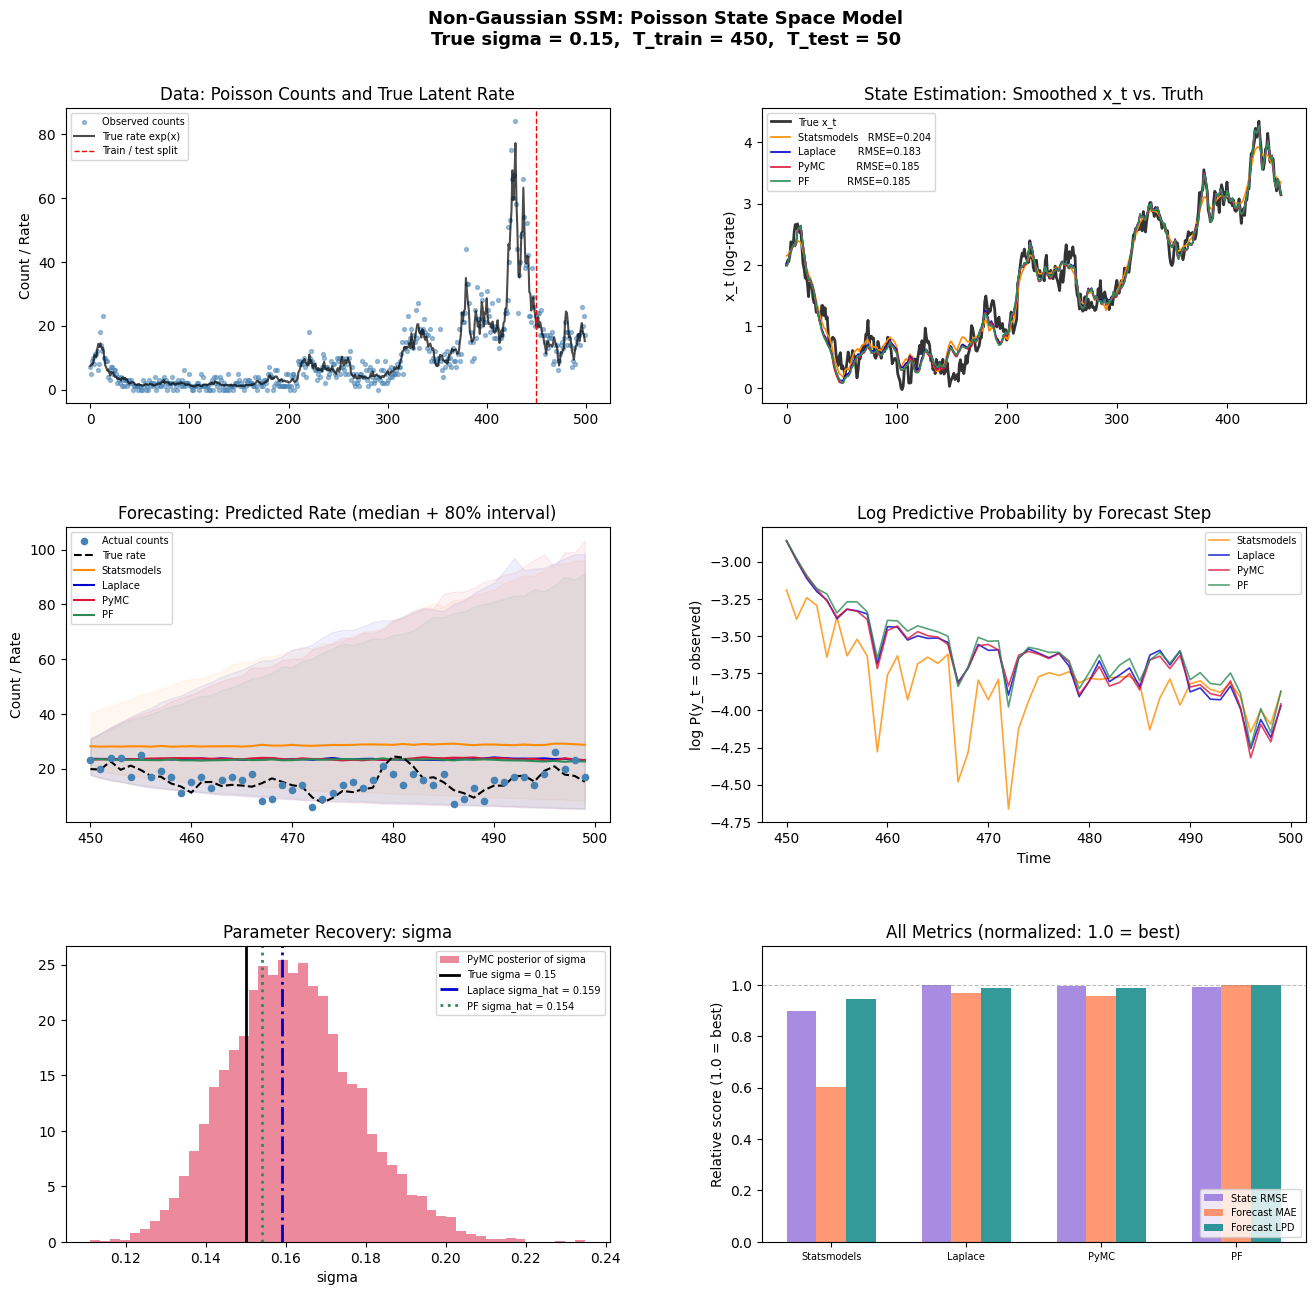

In [ ]:
# Plot all results
plot_all(
    filename="ssm_poisson_comparison.png",
    sigma_true=SIGMA_TRUE,
    T_train=T_TRAIN,
    T_test=T_TEST,
    x_true=x_true,
    y_all=y_all,
    x_train=x_train,
    x_test=x_test,
    y_test=y_test,
    models=model_info,
    rmses=[rmse1, rmse2, rmse3, rmse4],
    forecasts=forecast_info,
    maes=[mae1, mae2, mae3, mae4],
    lpds=[lpd1, lpd2, lpd3, lpd4],
    lpd_per_model=lpd_info,
    m2=m2,
    m3=m3,
    m4=m4,
)